# **PCA (Principal Component Analysis)** 

#### How does PCA work?

- Principal Component Analysis functions as an unsupervised preprocessing method. At its core, PCA utilizes orthogonal linear transformations to project dataset attributes onto a new coordinate system. This is, you can represent 3, 4, or 100 dimensions in a 2D coordinate system.
- In this transformed space, the **attribute capturing the greatest variance becomes the first principal component and occupies the first coordinate**. The **attribute with the second-highest variance becomes the second principal component**, and this pattern continues. 
- Effectively, the entire dataset can be represented through these principal components. Notably, in most cases, just two or three principal components can account for over 90% of the total variance.
- The fundamental purpose of PCA is dimensionality reduction—transforming data from high-dimensional to low-dimensional space by identifying and selecting the most significant attributes that retain maximum information about the dataset.


#### Where can you apply PCA?
- **Data visualization**: PCA reveals hidden correlations invisible to the naked eye, surfacing patterns that covariance matrices or single-variable analyses cannot detect.
- **Machine Learning optimization**: By reducing dimensionality, PCA decreases the number of variables in training and testing, significantly accelerating ML algorithm performance while preserving essential information.
- **Noise reduction**: PCA filters out minor components that often represent noise, resulting in cleaner datasets and more robust models.
- **Feature extraction**: PCA transforms original variables into uncorrelated principal components that capture the most significant aspects of your data, enabling more efficient analysis.

In [6]:
import pandas as pd

# Load the Wine dataset
df_wine = pd.read_csv('https://gist.githubusercontent.com/tijptjik/9408623/raw/b237fa5848349a14a14e5d4107dc7897c21951f5/wine.csv')

# Show a data sample
print(f"Sample:\n", df_wine.sample(10))

# Show some general statistics
print(f"\n\nDescription:\n", df_wine.describe())

Sample:
      Wine  Alcohol  Malic.acid   Ash   Acl   Mg  Phenols  Flavanoids  \
168     3    13.58        2.58  2.69  24.5  105     1.55        0.84   
149     3    13.08        3.90  2.36  21.5  113     1.41        1.39   
148     3    13.32        3.24  2.38  21.5   92     1.93        0.76   
174     3    13.40        3.91  2.48  23.0  102     1.80        0.75   
91      2    12.00        1.51  2.42  22.0   86     1.45        1.25   
34      1    13.51        1.80  2.65  19.0  110     2.35        2.53   
66      2    13.11        1.01  1.70  15.0   78     2.98        3.18   
73      2    12.99        1.67  2.60  30.0  139     3.30        2.89   
31      1    13.58        1.66  2.36  19.1  106     2.86        3.19   
97      2    12.29        1.41  1.98  16.0   85     2.55        2.50   

     Nonflavanoid.phenols  Proanth  Color.int   Hue    OD  Proline  
168                  0.39     1.54       8.66  0.74  1.80      750  
149                  0.34     1.14       9.40  0.57  1.33   

Steps: 
1. **Data standarization:** all the variables will have a mean 0 and std = 1 to prevent variables to dominate others just bc they have bigger values
2. **Calculate the covariance matrixes:** this tells us how variables are correlated (ej: if alcohol and color have positive covariance, when one increases, the other will also increase)
3. **Find the eigenvalues and eigenvectors:** 
    - The eigenvalues indicate how much information (variance) each principal component carries. 
    - The eigenvectors give you the direction of these components.
4. **Order and select the best components:** You typically choose the first 2 or 3, which explain most of the variance. This allows you to visualize data that was in 13 dimensions in just 2D.

**Data standardization**

In [7]:
from sklearn.discriminant_analysis import StandardScaler
from sklearn.model_selection import train_test_split
import numpy as np

# Split the dataset into features (X) and target labels (y).
# y: The first column (Wine) contains wine class types labels (1, 2, 3).
# X: All other columns (Alcohol, Malic.acid, etc.) are features for PCA
# * Why this? PCA is applied to features, not the target variable. This ensures we reduce the dimensionality of the input data, not the labels.
X = df_wine.iloc[:, 1:].values  # All columns except "Wine" (13 features)
y = df_wine.iloc[:, 0].values   # "Wine" column (class labels 1, 2, 3)

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, stratify=y, random_state=0)

# Standardize features (critical for PCA)
scaler = StandardScaler()
X_std = scaler.fit_transform(X)

**Perform PCA**

In [8]:
from sklearn.decomposition import PCA

# Perform PCA 
pca = PCA()
X_pca = pca.fit_transform(X_std)

**Compute the eigenvalues and eigenvectors**

In [16]:
# 1. Eigenvalues (Explained Variance)
explained_variance = pca.explained_variance_ratio_
cumulative_variance = np.cumsum(explained_variance)

# 2. Loadings (Component Coefficients)
loadings = pca.components_.T * np.sqrt(pca.explained_variance_)

# Print results
print("Explained Variance Ratios:", explained_variance)
print("Cumulative Variance:", cumulative_variance)
print("\nLoadings (PC1 and PC2):")
for i, feature in enumerate(df_wine.columns[1:]):
    print(f"{feature}: PC1={loadings[i, 0]:.2f}, PC2={loadings[i, 1]:.2f}")

Explained Variance Ratios: [0.36198848 0.1920749  0.11123631 0.0706903  0.06563294 0.04935823
 0.04238679 0.02680749 0.02222153 0.01930019 0.01736836 0.01298233
 0.00795215]
Cumulative Variance: [0.36198848 0.55406338 0.66529969 0.73598999 0.80162293 0.85098116
 0.89336795 0.92017544 0.94239698 0.96169717 0.97906553 0.99204785
 1.        ]

Loadings (PC1 and PC2):
Alcohol: PC1=0.31, PC2=0.77
Malic.acid: PC1=-0.53, PC2=0.36
Ash: PC1=-0.00, PC2=0.50
Acl: PC1=-0.52, PC2=-0.02
Mg: PC1=0.31, PC2=0.47
Phenols: PC1=0.86, PC2=0.10
Flavanoids: PC1=0.92, PC2=-0.01
Nonflavanoid.phenols: PC1=-0.65, PC2=0.05
Proanth: PC1=0.68, PC2=0.06
Color.int: PC1=-0.19, PC2=0.84
Hue: PC1=0.65, PC2=-0.44
OD: PC1=0.82, PC2=-0.26
Proline: PC1=0.62, PC2=0.58


**Eigenvectors (PCs) table**

In [38]:
# Create a DataFrame with the eigenvectors (PCs) and variable names
eigenvectors_df = pd.DataFrame(
    pca.components_.T, # Transpose to get variables as rows
    columns=[f'PC{i+1}' for i in range(pca.n_components_)],
    index=df_wine.columns[1:]  # Variable names (exclude the 'Wine' column)
)

# Just round to 3 decimal places
eigenvectors_df_rounded = eigenvectors_df.round(3)

# Show table
print("\nEigenvectors table:")
print(eigenvectors_df_rounded.to_markdown())


Eigenvectors table:
|                      |    PC1 |    PC2 |    PC3 |    PC4 |    PC5 |    PC6 |    PC7 |    PC8 |    PC9 |   PC10 |   PC11 |   PC12 |   PC13 |
|:---------------------|-------:|-------:|-------:|-------:|-------:|-------:|-------:|-------:|-------:|-------:|-------:|-------:|-------:|
| Alcohol              |  0.144 |  0.484 | -0.207 | -0.018 | -0.266 |  0.214 | -0.056 |  0.396 | -0.509 |  0.212 | -0.226 | -0.266 |  0.015 |
| Malic.acid           | -0.245 |  0.225 |  0.089 |  0.537 |  0.035 |  0.537 |  0.421 |  0.066 |  0.075 | -0.309 |  0.076 |  0.122 |  0.026 |
| Ash                  | -0.002 |  0.316 |  0.626 | -0.214 | -0.143 |  0.154 | -0.149 | -0.17  |  0.308 | -0.027 | -0.499 | -0.05  | -0.141 |
| Acl                  | -0.239 | -0.011 |  0.612 |  0.061 |  0.066 | -0.101 | -0.287 |  0.428 | -0.2   |  0.053 |  0.479 | -0.056 |  0.092 |
| Mg                   |  0.142 |  0.3   |  0.131 | -0.352 |  0.727 |  0.038 |  0.323 | -0.156 | -0.271 |  0.068 |  0.071 |  0.

☝️ Interpretation of the table above

Interpretation of the principal components is based on finding which variables are most strongly correlated with each component, i.e., which of these numbers are large in magnitude, the farthest from zero in either direction. Which numbers we consider to be large or small is of course a subjective decision. You need to determine at what level the correlation is of importance. Here a correlation above 0.5 is deemed important.  

- **Third Principal Component Analysis (PC2)**

*PC3 captures wines where Ash (mineral content) and Acl (organic acid) vary together. Wines with high PC3 scores have both higher Ash and Acl values, while low PC3 scores indicate lower values of both.* \*Important note: this kind of correlation mathematically imply that PC3 is a linear combination of Ash and Acl, weighted by their loadings

Domain Insight: High ash and acidity may indicate mineral-rich soils or specific fermentation practices.

- **Fifth Principal Component Analysis (PC5)**

*PC5 has a strong magnitude just at "Mg", which suggests this variable is quite independent from the others that have weak magnitudes in PCA5.*

Domain Insight: Magnesium levels may reflect vineyard soil composition or yeast nutrient additives during fermentation.

- **Sixth Principal Component Analysis (PC6)**

*PC6 has a medium correlation with two variables: Proanth and Malic.acid" which suggests that the Malic.acid is also influenced by the Proanth value and viceversa (note inverse values).*

Domain Insight: This inverse relationship may reflect trade-offs between tartness (malic acid) and astringency (proanthocyanidins) in wine.

- **Tenth Principal Component Analysis (PC10)**

*PC10 has a medium strong magnitude on Hue and OD. Interestingly they have opposed magnitudes -0.522 and 0.524, which suggests that they have a negative correlation which imply a trade-off among them.*

Domain Insight: This could indicate aging effects, where oxidation reduces red hue but increases density.

- **Therteenth Principal Component Analysis (PC13)**

*PC13 has a strong magnitude just at "Flavanoids", which suggests this variable is quite independent from the others that have weak magnitudes in PC13.*

Domain Insight: High flavanoid levels are prized in aged red wines for their tannin structure.

**Coavariance Matrix**
The covariance matrix is still useful, but it shows "only" pairwise relationships (variable vs. variable), while the eigenvectors table shows grouped relationships (variables vs. components).

If you had to visualithe the same relationships with a coavariance table, the dimensionality would imply 13x13 = 169 interactions (overwhelming) while the eigenvectors table is just 13 variables x 13 components in a structured, comprehensive view.

The Covariance Matrix tells us about direct correaltions while eigenvectors tells us about latent patterns .

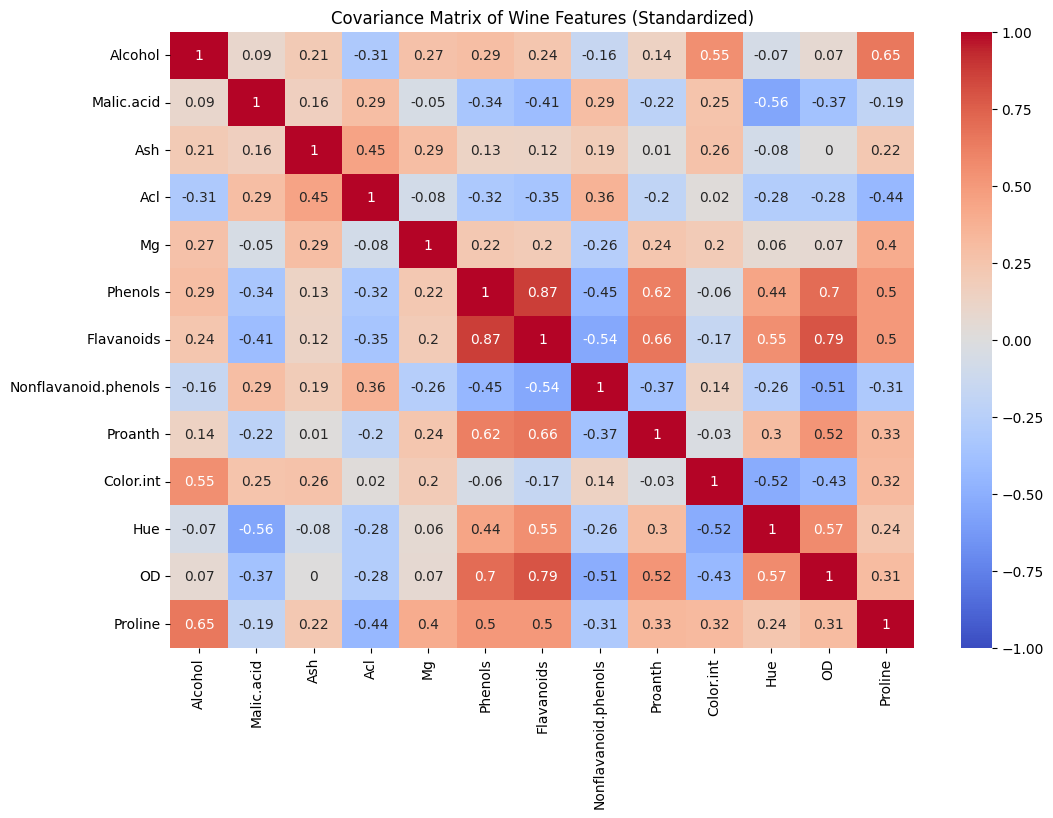

In [39]:
import seaborn as sns
import matplotlib.pyplot as plt

# Compute covariance matrix
cov_matrix = np.cov(X_std.T)

# Create DataFrame with variable names
cov_df = pd.DataFrame(
    cov_matrix,
    columns=df_wine.columns[1:],  # Exclude "Wine" column
    index=df_wine.columns[1:]
)

# Visualize with a heatmap
plt.figure(figsize=(12, 8))
sns.heatmap(cov_df.round(2), annot=True, cmap='coolwarm', vmin=-1, vmax=1)
plt.title("Covariance Matrix of Wine Features (Standardized)")
plt.show()

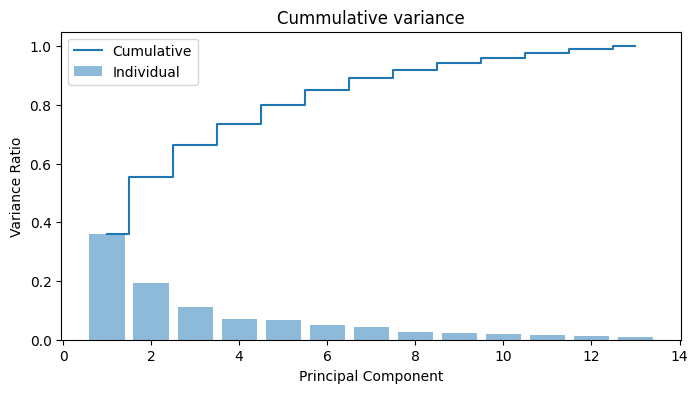

In [22]:
import matplotlib.pyplot as plt

# Variance plot
plt.figure(figsize=(8, 4))
plt.bar(range(1, 14), explained_variance, alpha=0.5, align='center', label='Individual')
plt.step(range(1, 14), cumulative_variance, where='mid', label='Cumulative')
plt.ylabel('Variance Ratio')
plt.xlabel('Principal Component')
plt.legend()
plt.title("Cummulative variance")
plt.show()

**Visualization of the variance**

☝️ Interpretation of the chart above: we can see that the 3 first components represent about 80% of the variance. This means we can represent the data in just that number of dimensions without loosing too much information. The line represents the cummulative variance.

\* *In case we needed 5 or 6 components to reach that 80%, is probably not worth it using this reduction system*

**Visualization**

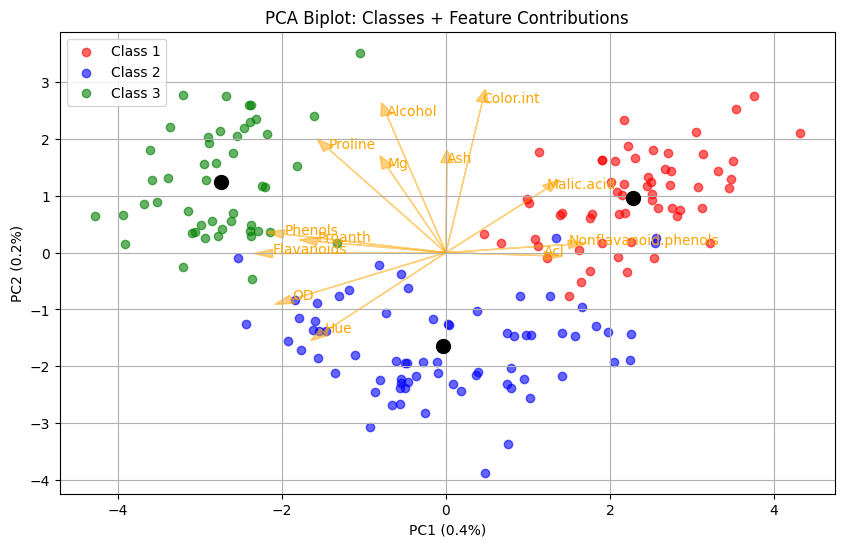

In [ ]:
# Biplot (Features + Samples)
plt.figure(figsize=(10, 6))
for l, c in zip(np.unique(y), ('r', 'b', 'g')):
    class_points = X_pca[y == l]
    plt.scatter(class_points[:, 0], class_points[:, 1], c=c, label=f'Class {l}', alpha=0.6)
    centroid = class_points.mean(axis=0)
    plt.plot(centroid[0], centroid[1], 'o', c='k', markersize=10)
    
# Add feature vectors
for i, feature in enumerate(df_wine.columns[1:]):
    plt.arrow(0, 0, loadings[i, 0]*5, loadings[i, 1]*5, color='Orange', alpha=0.5, head_width=0.15)
    plt.text(loadings[i, 0]*5, loadings[i, 1]*5, feature, color='Orange')

# Labels and tittle
plt.xlabel('PC1 ({}%)'.format(round(explained_variance[0], 1)))
plt.ylabel('PC2 ({}%)'.format(round(explained_variance[1], 1)))
plt.title("PCA Biplot: Classes + Feature Contributions")
plt.legend()
plt.grid()
plt.show()

☝️ Interpretation of the chart above: 
- The 3 colors correspond to wine classes (1-red, 2-blue, 3-green) from the original "Wine" column
- This shows how well PCA separates the different wine types in 2D space (PC1 and PC2).
- Arrows pointing in the same direction indicate positively correlated variables.
- Arrows pointing in opposite directions indicate negative correlations.
- Arrows at roughly 90 degrees suggest no (or very weak) correlation.
- Long arrows indicate variables with a strong contribution to the principal components.
- Arrows pointing toward a cluster suggest that those wine samples have higher values for those original variables. For instance, if class 3 appears opposite to the "Alcohol" arrow, it suggests lower alcohol levels on average.

#### Now what?

Now that you've successfully applied PCA to your dataset, revisit the **Where can you apply PCA?** section above to explore the practical applications of your transformed data. The dimensional reduction you've achieved has unlocked valuable analytical opportunities that can significantly enhance your data science workflow.